# Testing Differnet Methods for Detecting Bad Periods in EEG-fMRI Data

In [1]:
import numpy as np
import pandas as pd
import mne

from scipy.signal import welch, coherence
from scipy.stats import median_abs_deviation
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

In [47]:
raw.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x17d5da26a00) at 0x0000017D25232A80>

Channels marked as bad:
[np.str_('F4'), np.str_('F5'), np.str_('C5')]


In [2]:
# ----------------------------
# USER SETTINGS
# ----------------------------

n_slices = 11
TR = 1.5

tr_freq = 1 / TR          # 0.667 Hz
slice_freq = n_slices / TR  # 7.33 Hz

n_harmonics = 5

window_sec = 20
overlap = 0.5

# ----------------------------
# LOAD DATA
# ----------------------------

raw = mne.io.read_raw('sub-01_ses-sleep_task-sleep_run-01_preproc_cropped.edf', preload=True)
raw = raw.copy().pick("eeg")

sfreq = raw.info["sfreq"]

data = raw.get_data()
channels = raw.ch_names


Extracting EDF parameters from c:\Users\brand\Documents\eegfmri_denoising\notebooks\sub-01_ses-sleep_task-sleep_run-01_preproc_cropped.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 600499  =      0.000 ...  1200.998 secs...


In [10]:
freqs, psd = welch(
    data,
    fs=sfreq,
    axis=1,
    nperseg=int(sfreq * 2),
    noverlap=int(sfreq),
)


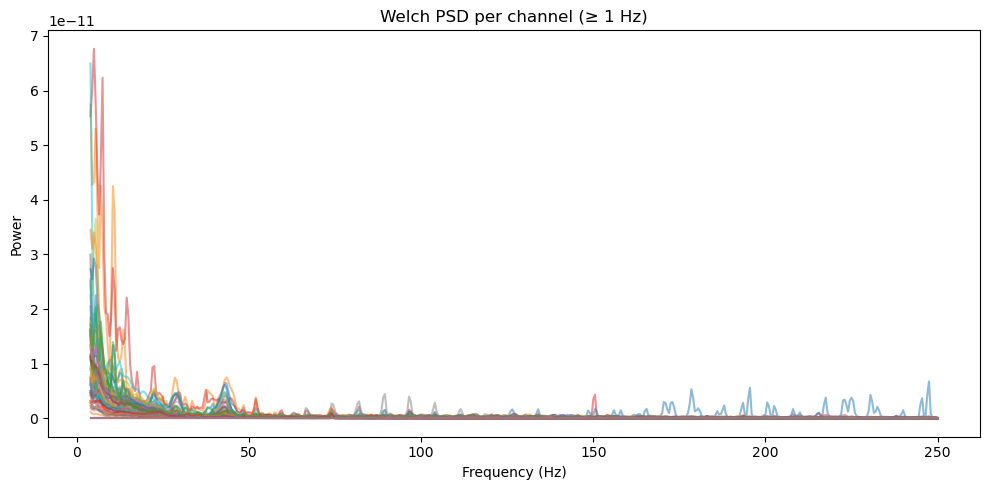

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# mask frequencies >= 1 Hz
mask = freqs >= 4

plt.figure(figsize=(10, 5))

for ch_idx in range(psd.shape[0]):
    plt.plot(freqs[mask], psd[ch_idx, mask], alpha=0.5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Welch PSD per channel (≥ 1 Hz)")

plt.tight_layout()
plt.show()

In [11]:
def band_power(freqs, psd, targets, width=0.5):

    mask = np.zeros_like(freqs, dtype=bool)

    for f in targets:
        mask |= np.abs(freqs - f) < width

    return psd[:, mask].sum(axis=1)

## Residual harmonic power

In [12]:

harmonics = []

for k in range(1, n_harmonics + 1):
    harmonics.append(slice_freq * k)
    harmonics.append(tr_freq * k)

harmonics = np.array(harmonics)

# ----------------------------
# 1 Residual harmonic power
# ----------------------------

artifact_power = band_power(freqs, psd, harmonics)

total_power = psd.sum(axis=1)

residual_ratio = artifact_power / total_power

# robust z
residual_z = (
    residual_ratio - np.median(residual_ratio)
) / median_abs_deviation(residual_ratio)

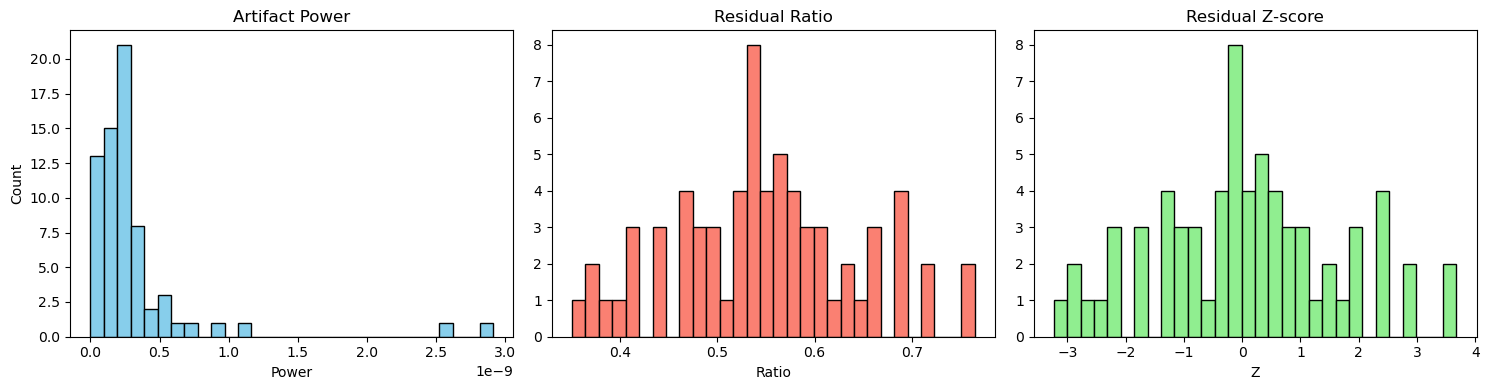

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Artifact power
axes[0].hist(artifact_power, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title("Artifact Power")
axes[0].set_xlabel("Power")
axes[0].set_ylabel("Count")

# 2. Residual ratio
axes[1].hist(residual_ratio, bins=30, color='salmon', edgecolor='black')
axes[1].set_title("Residual Ratio")
axes[1].set_xlabel("Ratio")

# 3. Residual z-score
axes[2].hist(residual_z, bins=30, color='lightgreen', edgecolor='black')
axes[2].set_title("Residual Z-score")
axes[2].set_xlabel("Z")

plt.tight_layout()
plt.show()

In [26]:
import pandas as pd

df = pd.DataFrame({
    "channel": ch_names,
    "artifact_power": artifact_power
})

df = df.sort_values("artifact_power", ascending=False)
print(df)

   channel  artifact_power
1      Fp2    2.910526e-09
3       F4    2.554821e-09
62     Fpz    1.073521e-09
0      Fp1    9.624495e-10
29    TP10    7.590783e-10
..     ...             ...
31     ECG    5.442391e-20
64    CWL1    5.569780e-22
67    CWL4    4.864659e-22
65    CWL2    2.235830e-22
66    CWL3    1.206194e-22

[68 rows x 2 columns]


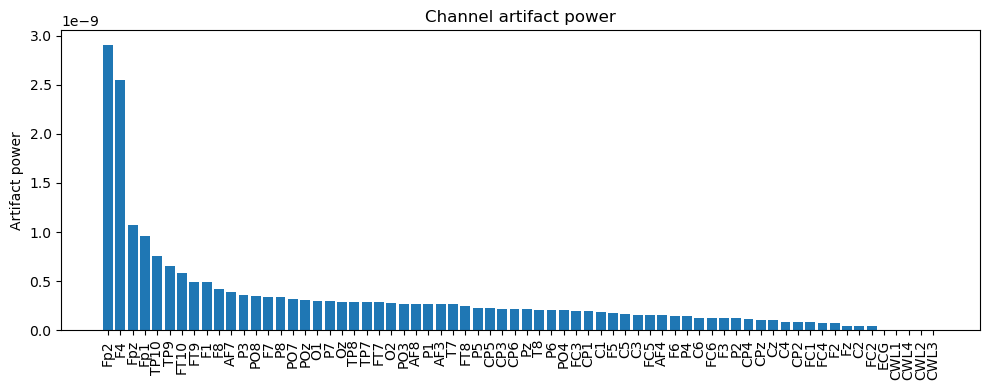

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.bar(df["channel"], df["artifact_power"])

plt.xticks(rotation=90)
plt.ylabel("Artifact power")
plt.title("Channel artifact power")


plt.tight_layout()
plt.show()

In [29]:
raw.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x17d41478d70) at 0x0000017D24345E40>

Channels marked as bad:
[np.str_('F4'), np.str_('FC3'), np.str_('F5'), np.str_('C5')]


## Coherence to average EEG

In [14]:
reference = np.mean(data, axis=0)

coh_scores = []

for ch in data:

    f, cxy = coherence(
        ch,
        reference,
        fs=sfreq,
        nperseg=int(sfreq * 4)
    )

    mask = np.isin(
        np.round(f, 1),
        np.round(harmonics, 1)
    )

    coh_scores.append(np.mean(cxy[mask]))

coh_scores = np.array(coh_scores)

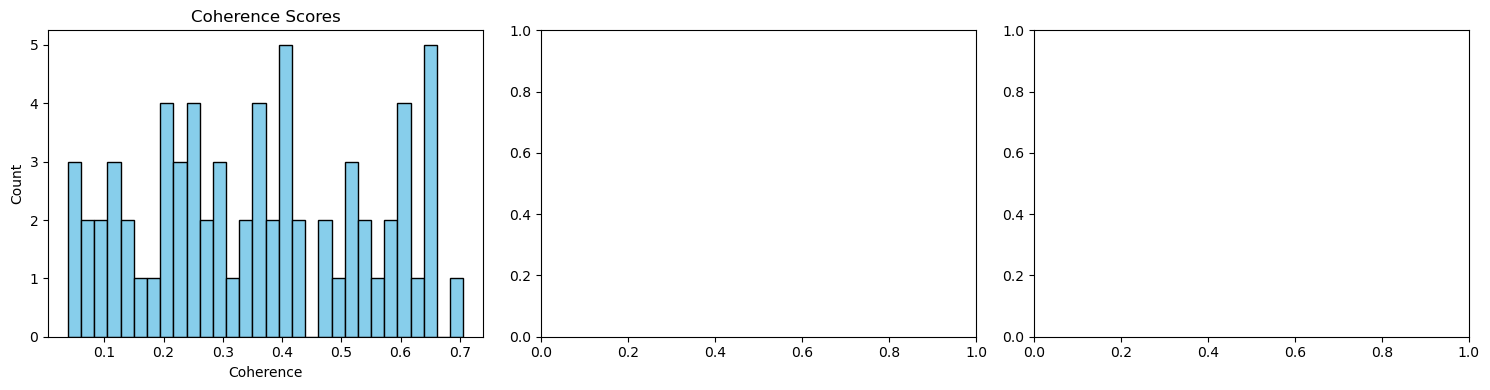

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(coh_scores, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title("Coherence Scores")
axes[0].set_xlabel("Coherence")
axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()


# Harmonic Fingerprint

In [16]:
harmonic_fraction = (
    artifact_power /
    total_power
)

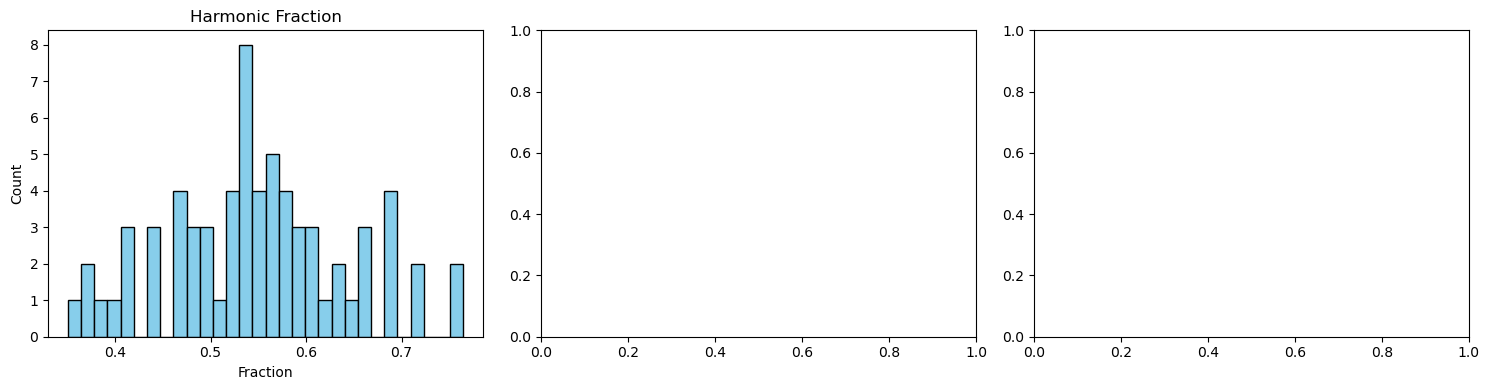

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(harmonic_fraction, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title("Harmonic Fraction")
axes[0].set_xlabel("Fraction")
axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()


## Sliding Window

In [18]:
step = int(window_sec * sfreq * (1 - overlap))
win = int(window_sec * sfreq)

segment_scores = []

for start in range(0, data.shape[1] - win, step):

    seg = data[:, start:start+win]

    f, p = welch(
        seg,
        fs=sfreq,
        axis=1
    )

    ap = band_power(
        f,
        p,
        harmonics
    )

    segment_scores.append(
        ap /p.sum(axis=1)
    )

segment_scores = np.array(segment_scores)

In [19]:
np.shape(segment_scores)

(119, 68)

In [49]:
np.min(segment_scores)

np.float64(2.198035059483198e-24)

In [50]:
np.max(segment_scores)

np.float64(1.5963300704902283e-08)

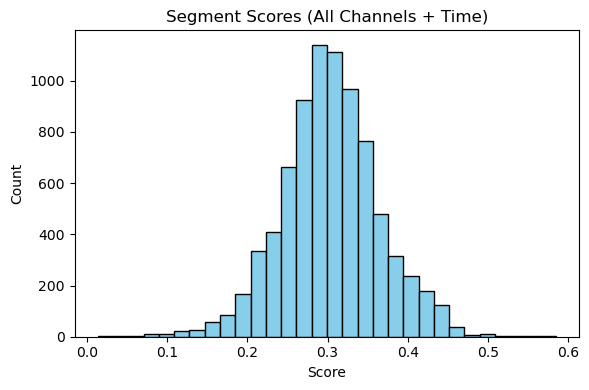

In [58]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))

axes.hist(segment_scores.ravel(), bins=30, color='skyblue', edgecolor='black')

axes.set_title("Segment Scores (All Channels + Time)")
axes.set_xlabel("Score")
axes.set_ylabel("Count")

plt.tight_layout()
plt.show()

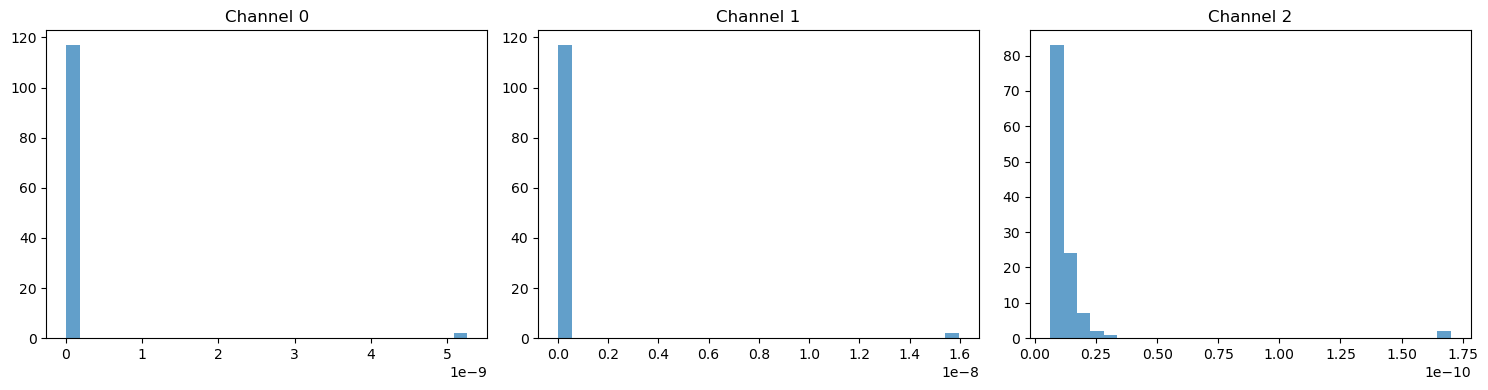

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):  # first 3 channels
    axes[i].hist(segment_scores[:, i], bins=30, alpha=0.7)
    axes[i].set_title(f"Channel {i}")

plt.tight_layout()
plt.show()

## Autocorrelation periodicity (NOGO)

In [ ]:
tr_lag = int(sfreq / tr_freq)

auto_scores = []

for ch in data:

    ac = np.correlate(
        ch,
        ch,
        mode="full"
    )

    ac = ac[len(ac)//2:]

    auto_scores.append(
        ac[tr_lag] / ac[0]
    )

auto_scores = np.array(auto_scores)

## Spatial PSD deviation

In [20]:
median_psd = np.median(psd, axis=0)

spatial_dev = cdist(
    psd,
    median_psd[None],
    metric="euclidean"
).flatten()

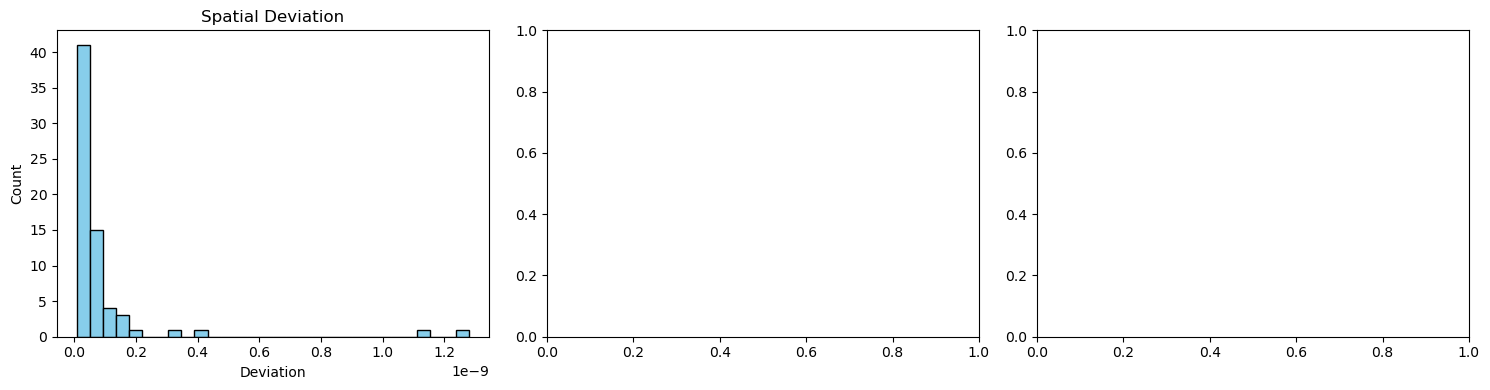

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(spatial_dev, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title("Spatial Deviation")
axes[0].set_xlabel("Deviation")
axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()


In [23]:
ch_names = raw.ch_names

In [24]:
import pandas as pd

df = pd.DataFrame({
    "channel": ch_names,
    "spatial_dev": spatial_dev
})

df = df.sort_values("spatial_dev", ascending=False)
print(df)

   channel   spatial_dev
1      Fp2  1.281326e-09
3       F4  1.132319e-09
62     Fpz  3.916328e-10
0      Fp1  3.323864e-10
29    TP10  2.083195e-10
..     ...           ...
26     CP5  1.360674e-11
13      T8  1.326701e-11
45     PO4  1.115085e-11
50      P5  9.187758e-12
18      Pz  7.921244e-12

[68 rows x 2 columns]


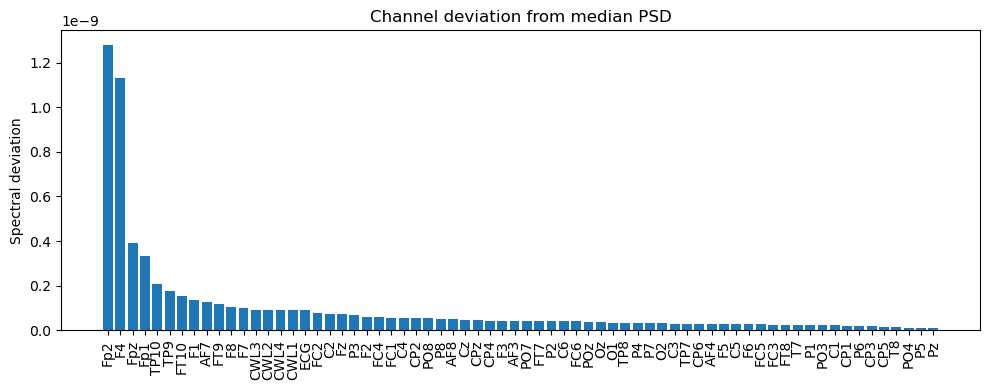

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.bar(df["channel"], df["spatial_dev"])

plt.xticks(rotation=90)
plt.ylabel("Spectral deviation")
plt.title("Channel deviation from median PSD")

plt.tight_layout()
plt.show()

In [22]:
# ----------------------------
# COMBINE
# ----------------------------

results = pd.DataFrame({
    "channel": channels,
    "residual_z": residual_z,
    "coherence": coh_scores,
    "harmonic_fraction": harmonic_fraction,
    #"periodicity": auto_scores,
    "spatial_dev": spatial_dev
})

print(
    results.sort_values(
        "residual_z",
        ascending=False
    )
)

# candidate bad
bad = results.loc[
    (
        (results.residual_z > 3)
        |
        (results.coherence > np.percentile(coh_scores, 95))
    ),
    "channel"
]

print("\nCandidate bad channels:")
print(list(bad))

   channel  residual_z  coherence  harmonic_fraction   spatial_dev
62     Fpz    3.675412   0.286278           0.764712  3.916328e-10
1      Fp2    3.572537   0.166748           0.758546  1.281326e-09
3       F4    2.820420   0.073306           0.713470  1.132319e-09
34      C1    2.760183   0.241432           0.709860  2.154580e-11
17      Cz    2.434750   0.203728           0.690356  4.643229e-11
..     ...         ...        ...                ...           ...
48      C5   -2.490750   0.508513           0.395159  2.706200e-11
27     CP6   -2.575304   0.359740           0.390092  2.907777e-11
24     FC5   -2.818148   0.367009           0.375538  2.680823e-11
40     FC3   -2.832442   0.350289           0.374681  2.535502e-11
25     FC6   -3.234341   0.143763           0.350594  3.923180e-11

[68 rows x 5 columns]

Candidate bad channels:
['Fp2', 'PO3', 'PO4', 'P5', 'P6', 'Fpz']


In [31]:
hf_band = (40, min(0.45 * sfreq, 120))

In [32]:
from scipy.signal import welch
import numpy as np

win_sec = 5
step = int(win_sec * sfreq)

hf_scores = []

for start in range(0, data.shape[1] - step, step):

    seg = data[:, start:start+step]

    f, p = welch(seg, fs=sfreq, axis=1, nperseg=step)

    mask = (f >= hf_band[0]) & (f <= hf_band[1])

    hf_power = p[:, mask].mean(axis=1)

    total_power = p.mean(axis=1)

    hf_scores.append(hf_power / total_power)

hf_scores = np.array(hf_scores)

In [34]:
segment_score = hf_scores.mean(axis=1)

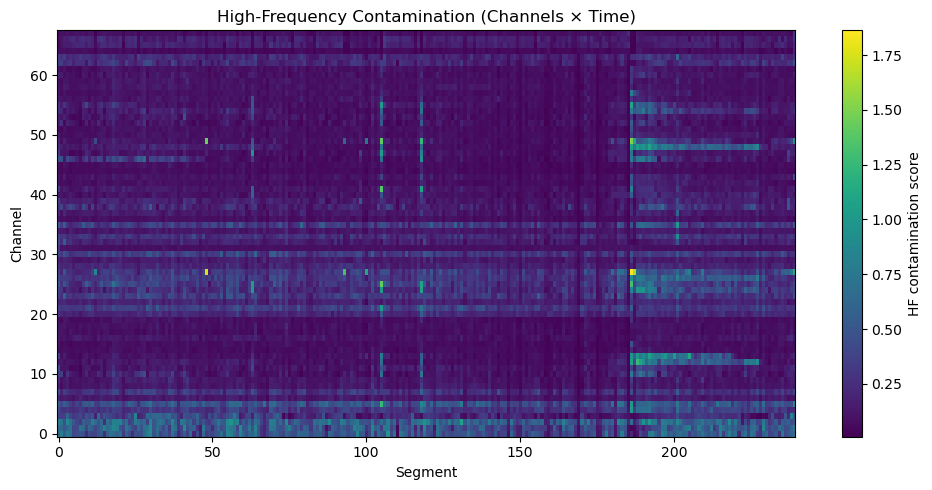

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.imshow(
    hf_scores.T,
    aspect='auto',
    origin='lower'
)

plt.colorbar(label="HF contamination score")

plt.xlabel("Segment")
plt.ylabel("Channel")
plt.title("High-Frequency Contamination (Channels × Time)")

plt.tight_layout()
plt.show()

In [36]:
# pip install autoreject
import mne
from autoreject import AutoReject

In [39]:
raw.drop_channels(
    ["ECG", "CWL1", "CWL2", "CWL3", "CWL4"]
)

<RawEDF | sub-01_ses-sleep_task-sleep_run-01_preproc_cropped.edf, 63 x 600500 (1201.0 s), ~288.7 MiB, data loaded>

In [44]:
raw.set_montage("standard_1020")

<RawEDF | sub-01_ses-sleep_task-sleep_run-01_preproc_cropped.edf, 63 x 600500 (1201.0 s), ~288.7 MiB, data loaded>

In [45]:
# create fixed-length epochs (e.g. 2 seconds)
epochs = mne.make_fixed_length_epochs(
    raw,
    duration=1.5,
    overlap=0.5,
    preload=True
)

Not setting metadata
1200 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1200 events and 750 original time points ...
1 bad epochs dropped


In [46]:
ar = AutoReject(
    n_interpolate=[1, 2, 4],   # channels to interpolate
    random_state=42,
    n_jobs=1
)

epochs_clean = ar.fit_transform(epochs)

i:\Software\mne\Lib\site-packages\autoreject\utils.py:73: UserWarning: 4 channels are marked as bad. These will be ignored. If you want them to be considered by autoreject please remove them from epochs.info["bads"].
  warnings.warn(


Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/59 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/59 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/1199 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

KeyboardInterrupt: 